<a href="https://colab.research.google.com/github/bonfito/GroupF/blob/main/Notebooks/03_generativeDiffPir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In questo NB viene modificata l'architettura del DiffPIR a 256x256, per fare questo sono state seguite le seguenti accortezze:

1) Si aggiunge un livello di profondità in più. Si passa da

```
channel_mults(1,2,4) a (1,2,4,8)
```
aggiunto un livello di downsampling. In questo modo l'immagine a 256x256 viene ridotta più volte, passando da 256->128->64->32 in modo che i blocchi più pesanti lavorino a risoluzioni gestibili.


2) L'attenzione viene spostata solo in fondo.
Nell'homework 2 del prof Evangelista l'attenzione era su livelli ad alta risoluzione, ma lì le immagini erano state ridimensionate a 64*64, con 256x256 sarebbe proibitivo per la memoria (il costo dell'attenzione cresce con il quadrato dei pixel).
L'attenzione si sposta quindi solo sul livello più profondo, ovvero a 32x32

# Training

In [ ]:
#  TRAINING DENOISER RETINA 256x256
import sys, types, glob, shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

book_root   = Path('/content/drive/MyDrive/Imaging')
ipp_root    = book_root / 'IPPy'
data_root   = book_root / 'project' / 'data' / 'retina' / 'retinal_data' / 'images'   # <-- come i colleghi
weights_dir = book_root / 'project' / 'weights'
weights_dir.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ipp_root))
sys.modules['astra'] = types.ModuleType('astra')

import torch
import torch.nn.functional as F
from torch import nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm.auto import tqdm

from utilities import get_device
from nn.diffusion import DiffusionUNet, EMA, cosine_beta_schedule, extract

device = get_device()
print('Device:', device)


MAX_IMAGES = 4000
fname_list = sorted(glob.glob(f"{data_root}/**/*.png", recursive=True))[:MAX_IMAGES]

n_total = len(fname_list)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

indices = list(range(n_total))
train_idx, val_idx, test_idx = random_split(
    indices, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)
train_files = [fname_list[i] for i in train_idx]
print(f'Train: {len(train_files)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

# Copia in locale SOLO i file di train (per la velocità I/O)
local_train = Path('/content/retina_train')
local_train.mkdir(parents=True, exist_ok=True)
local_train_files = []
for i, src in enumerate(train_files):
    dst = local_train / f'{i:05d}.png'      # nome indicizzato: evita collisioni di nome
    if not dst.exists():
        shutil.copy(src, dst)
    local_train_files.append(str(dst))
print('Immagini train locali:', len(local_train_files))

#  Dataset basato su lista di file (in [-1,1])
class RetinaDataset(Dataset):
    def __init__(self, file_list, data_shape=256):
        self.fname_list = file_list
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
    def __len__(self):
        return len(self.fname_list)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.fname_list[idx]))

train_dataset = RetinaDataset(local_train_files, data_shape=256)
train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True,
                           num_workers=2, pin_memory=True)
print('Train:', len(train_dataset), '| batch: 4')

# Schedule di diffusione
num_diffusion_steps = 400
betas      = cosine_beta_schedule(num_diffusion_steps)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

#  Modello adattato a 256x256
torch.manual_seed(0)
target_epochs = 30
learning_rate = 2e-4
weight_decay  = 1e-4
ema_decay     = 0.9995
grad_clip     = 1.0

model = DiffusionUNet(
    in_ch=1, base_ch=64, channel_mults=(1, 2, 4, 8),   # +1 livello
    time_dim=256, dropout=0.05, attn_levels=(3,),       # attenzione solo a 32x32
).to(device)
ema = EMA(model, decay=ema_decay)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=target_epochs)
scaler    = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))

weights_path = weights_dir / 'DDPMDenoiser_retina.pth'
ckpt_path    = weights_dir / 'DDPMDenoiser_retina.ckpt'

#  implementazione checkpoint nel caso di interruzioni
start_epoch, best_loss, history = 0, float('inf'), []
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model']);      ema.load_state_dict(ckpt['ema'])
    optimizer.load_state_dict(ckpt['optimizer']); scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    start_epoch = ckpt['epoch'] + 1
    best_loss   = ckpt['best_loss']; history = ckpt['history']
    print(f'Ripreso dal checkpoint: riparto dall\'epoca {start_epoch + 1}.')
else:
    print('Training da zero.')

# Loop
for epoch in range(start_epoch, target_epochs):
    model.train()
    epoch_loss = 0.0
    bar = tqdm(train_loader, desc=f'epoch {epoch+1}/{target_epochs}', leave=True)
    for step, x0 in enumerate(bar, start=1):
        x0 = x0.to(device, non_blocking=True)
        t = torch.randint(0, num_diffusion_steps, (x0.shape[0],), device=device)
        noise = torch.randn_like(x0)
        x_t = (extract(alpha_bars.sqrt(), t, x0.shape) * x0
               + extract((1 - alpha_bars).sqrt(), t, x0.shape) * noise)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device == 'cuda')):
            noise_pred = model(x_t, t)
            loss = F.mse_loss(noise_pred, noise)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        ema.update(model)
        epoch_loss += loss.item()
        bar.set_postfix(loss=f'{loss.item():.4f}', avg=f'{epoch_loss/step:.4f}')

    epoch_loss /= len(train_loader)
    history.append(epoch_loss)
    scheduler.step()

    # Salva i pesi EMA migliori + checkpoint per la ripresa (ogni epoca)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(ema.shadow.state_dict(), weights_path)
    torch.save({'epoch': epoch, 'model': model.state_dict(), 'ema': ema.state_dict(),
                'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
                'scaler': scaler.state_dict(), 'history': history, 'best_loss': best_loss},
               ckpt_path)

print(f'\n Pesi EMA salvati in: {weights_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Train: 2800 | Val: 600 | Test: 600
Immagini train locali: 2800
Train: 2800 | batch: 4
Training da zero.


/tmp/ipykernel_10798/595901325.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))


epoch 1/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 2/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 3/30:   0%|          | 0/700 [00:00<?, ?it/s]

...

epoch 27/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 28/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 29/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 30/30:   0%|          | 0/700 [00:00<?, ?it/s]


 Pesi EMA salvati in: /content/drive/MyDrive/Imaging/project/weights/DDPMDenoiser_retina.pth


essendo che le immagini sono ridimensionate a 256x256 piuttosto che a 64x64, un batch grande non ci starebbe e si andrebbe in out of memory. Motivo per cui il batch viene limitato a 4.
Diciamo che è un compromesso, dè un batch abbastanza piccolo per entrare in memoria, ma abbastanza grande da dare un gradiente abbastanza stabile.

Tuttavia, un batch più piccolo indica un gradiente un po' più rumoroso (quindi meno immagini su cui mediare ad ogni passo).
Questo però non dovrebbe essere un problema con la diffusione, perché mediamo su tantissimi passi.




# Ricarico il tutto




In [ ]:
import sys, types, glob
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

book_root   = Path('/content/drive/MyDrive/Imaging')
ipp_root    = book_root / 'IPPy'
data_root   = book_root / 'project' / 'data' / 'retina' / 'retinal_data' / 'images'
weights_dir = book_root / 'project' / 'weights'

sys.path.append(str(ipp_root))
sys.modules['astra'] = types.ModuleType('astra')

import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, random_split
from torchvision import transforms

import operators
from utilities import get_device
from utilities.metrics import PSNR, SSIM
from nn.diffusion import DiffusionUNet, cosine_beta_schedule, extract, denormalize_to_01

device = get_device()
print('Device:', device)

# Schedule identico al training
num_diffusion_steps = 400
betas      = cosine_beta_schedule(num_diffusion_steps)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Denoiser 256x256
model = DiffusionUNet(
    in_ch=1, base_ch=64, channel_mults=(1, 2, 4, 8),
    time_dim=256, dropout=0.05, attn_levels=(3,),
).to(device)
model.load_state_dict(torch.load(weights_dir / 'DDPMDenoiser_retina.pth', map_location=device))
model.eval()
print('Denoiser caricato.')


MAX_IMAGES = 4000
fname_list = sorted(glob.glob(f"{data_root}/**/*.png", recursive=True))[:MAX_IMAGES]
n_total = len(fname_list)
n_train = int(0.70 * n_total); n_val = int(0.15 * n_total); n_test = n_total - n_train - n_val
indices = list(range(n_total))
train_idx, val_idx, test_idx = random_split(
    indices, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)
val_files  = [fname_list[i] for i in val_idx]
test_files = [fname_list[i] for i in test_idx]

class RetinaDataset(Dataset):
    def __init__(self, file_list, data_shape=256):
        self.fname_list = file_list
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
    def __len__(self): return len(self.fname_list)
    def __getitem__(self, idx): return self.transform(Image.open(self.fname_list[idx]))

test_dataset = RetinaDataset(test_files, data_shape=256)
val_dataset  = RetinaDataset(val_files,  data_shape=256)
print('Test:', len(test_dataset), '| Val:', len(val_dataset))

# Operatore K — invariato
K = operators.Blurring(img_shape=(256, 256), kernel_type='motion',
                       kernel_size=9, motion_angle=45)
print('Operatore K pronto.')

Mounted at /content/drive
Device: cuda
Denoiser caricato.
Test: 332 immagini
Val: 330 immagini
Operatore K pronto.


# Funzioni DiffPIR


In [ ]:
def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    return (
        x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred
    ) / extract(alpha_bars.sqrt(), t, x_t.shape)

def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred

def diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.5):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long)
    x = y_delta.clone()
    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next    = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)
        with torch.no_grad():
            eps_pred = model(x, t)
            x0_hat   = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
            x_prior  = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            residual = K(x_prior) - y_delta
            x = (x_prior - tau * K.T(residual)).clamp(-1.0, 1.0)
    return x.clamp(-1.0, 1.0).detach()

print('Funzioni DiffPIR definite.')

Funzioni DiffPIR definite.


# Test su immagine con i 4 livelli di rumore
per ognuno dei 4 livelli di rumore, viene costruita la misura corrotta, poi si passa a ricostruzione con diffpir.

Noise      PSNR (dB)      SSIM
0.005         27.320    0.8499
0.01          27.395    0.8508
0.05          27.177    0.8365
0.1           26.907    0.7641


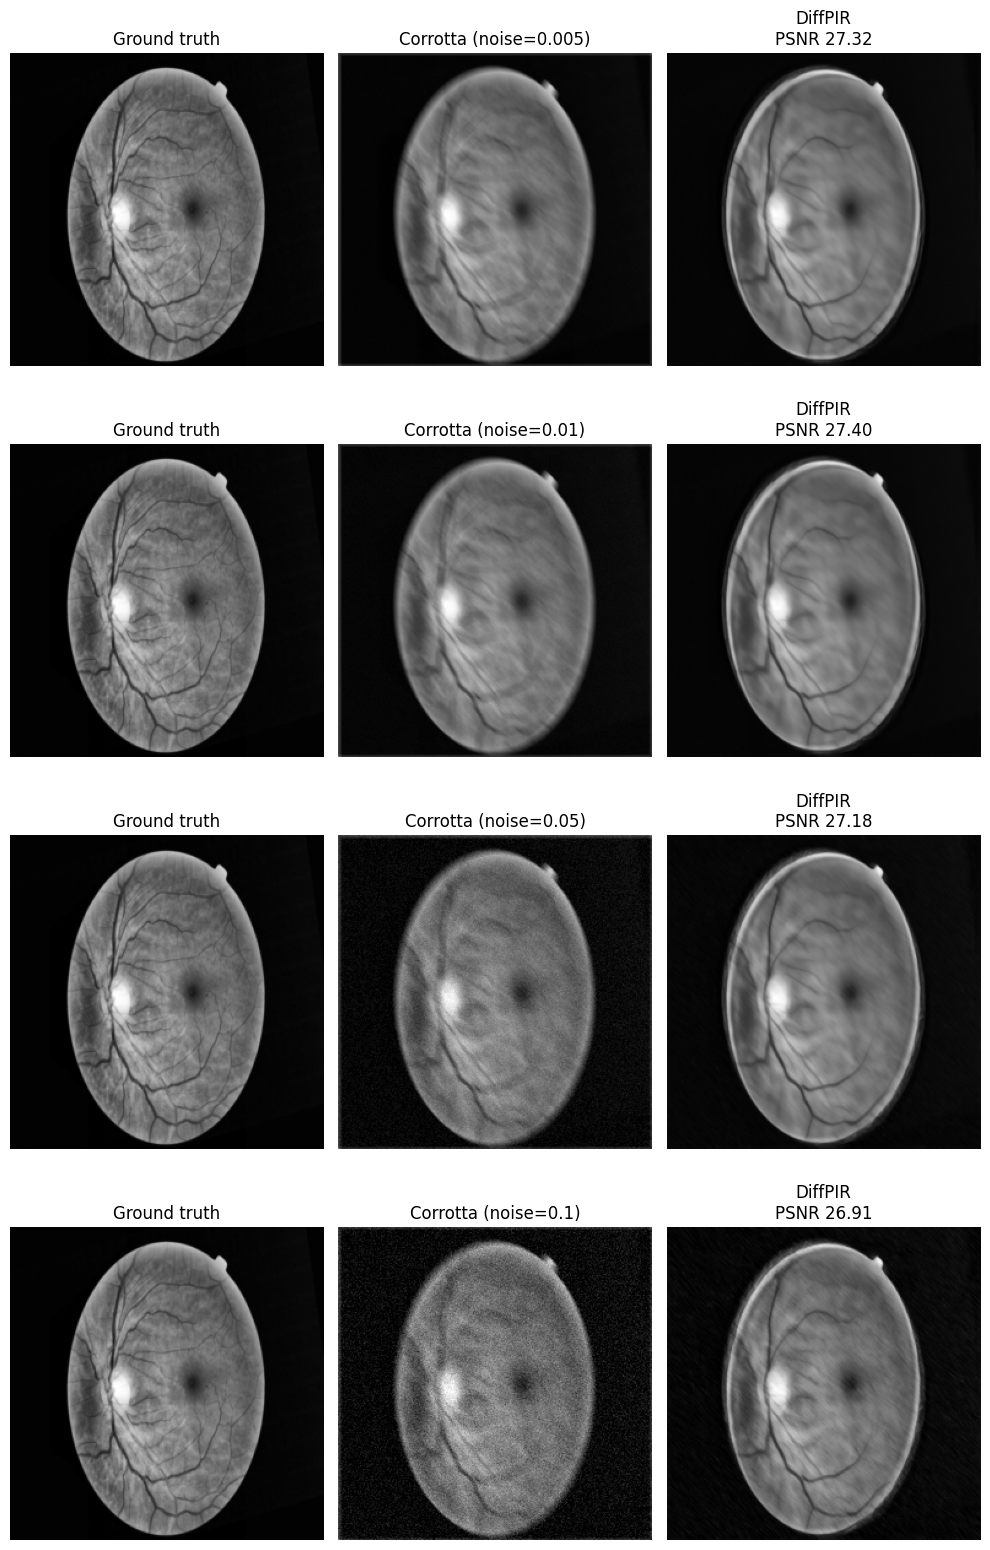

In [ ]:
noise_levels = [0.005, 0.01, 0.05, 0.1]

x_true = test_dataset[0].unsqueeze(0).to(device)
x_true_01 = denormalize_to_01(x_true).cpu()

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(10, 4 * len(noise_levels)))
print(f"{'Noise':<8}{'PSNR (dB)':>12}{'SSIM':>10}")

for r, nl in enumerate(noise_levels):
    torch.manual_seed(0)
    with torch.no_grad():
        y_delta = K(x_true) + nl * torch.randn_like(x_true)
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.5)

    y_01   = denormalize_to_01(y_delta).cpu()
    rec_01 = denormalize_to_01(x_rec).cpu()
    psnr = PSNR(rec_01, x_true_01)
    ssim = SSIM(rec_01, x_true_01)
    print(f"{nl:<8}{psnr:>12.3f}{ssim:>10.4f}")

    axes[r, 0].imshow(x_true_01.squeeze(), cmap='gray'); axes[r, 0].set_title('Ground truth'); axes[r, 0].axis('off')
    axes[r, 1].imshow(y_01.squeeze(), cmap='gray');      axes[r, 1].set_title(f'Corrotta (noise={nl})'); axes[r, 1].axis('off')
    axes[r, 2].imshow(rec_01.squeeze(), cmap='gray');    axes[r, 2].set_title(f'DiffPIR\nPSNR {psnr:.2f}'); axes[r, 2].axis('off')

plt.tight_layout(); plt.show()

# Risultati 40 epoche
Effettuando un training a 40 epoche, si sono ottenuti i seguenti risultati:

| Noise | PSNR (dB) | SSIM   |
|-------|-----------|--------|
| 0.005 | 27.320    | 0.8499 |
| 0.01  | 27.395    | 0.8508 |
| 0.05  | 27.177    | 0.8365 |
| 0.1   | 26.907    | 0.7641 |

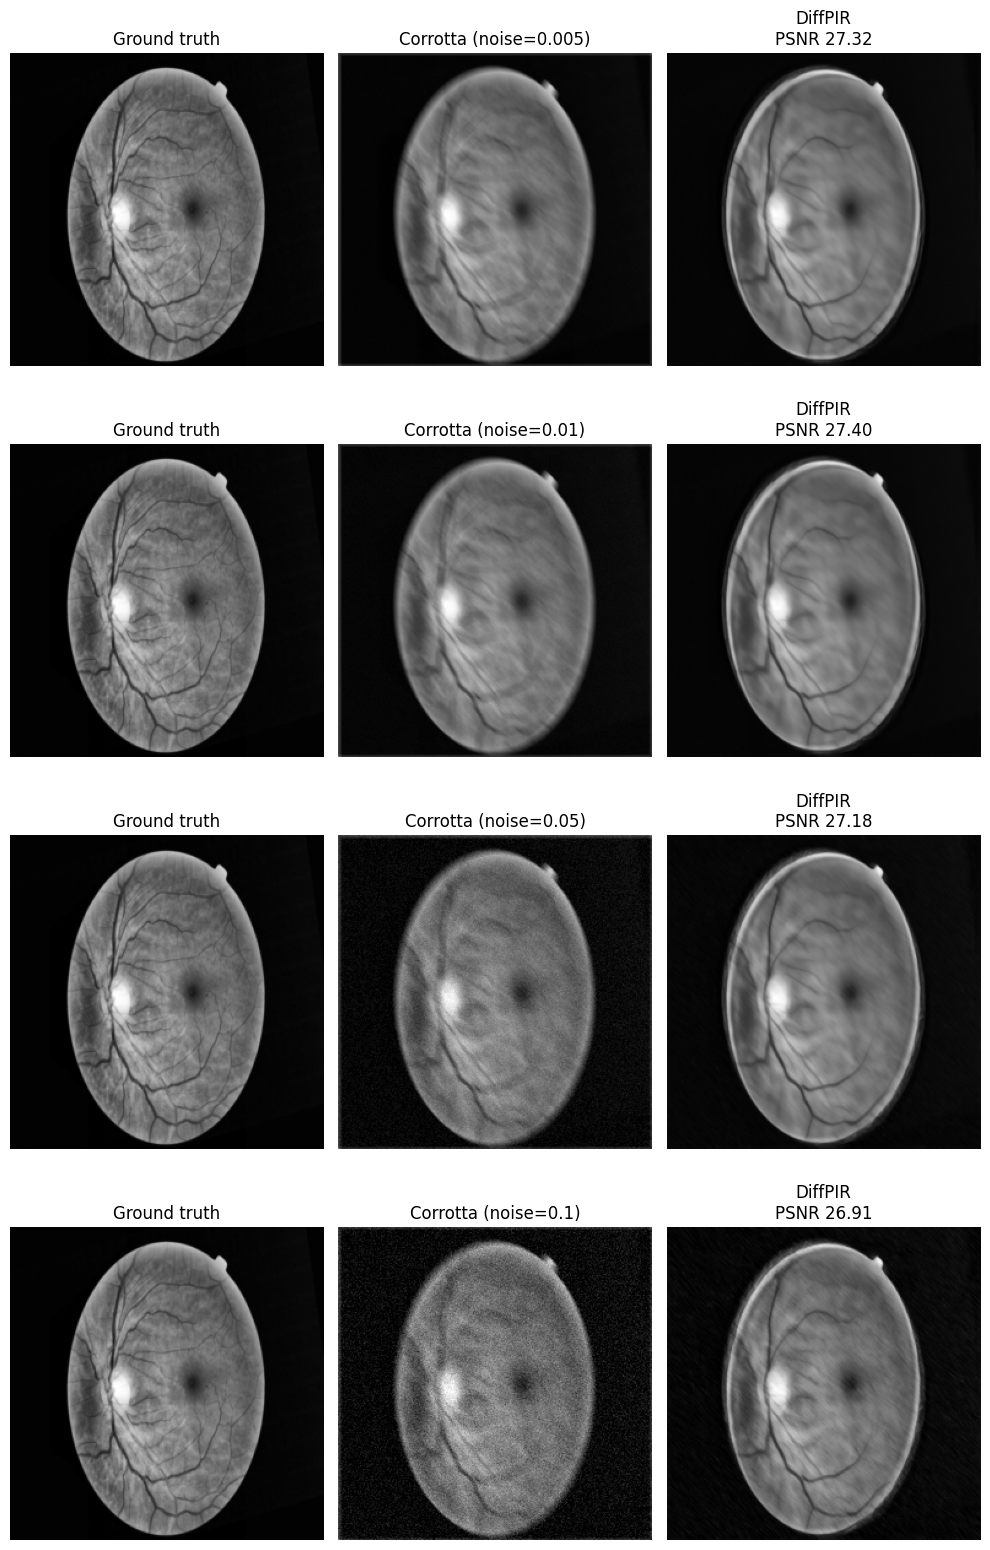


# Spiegazione/Osservazione Risultati (su 40 epoche)


1) **Il Diffpir riesce a recuperare abbastanza bene il deblur**


*   Le ricostruzioni sono nettamente più nitide delle corrotte. Come possiamo osservare i vasi sanguigni e il disco ottico (in bianco sulla sinistra) sono ben definiti rispetto alla misura corrotta.


2.   **Robustezza al rumore**


*   Man mano che cresce il rumore (passando da 0.005 a 0.1) la misura ovviamente peggiora (possiamo osservare come l'ultima misura sia sommersa dal rumore). Tuttavia possiamo notare che la r**icostruzione Diffpir rimane piuttosto stabile**.
Dai dati della tabella PSNR scende soltanto da 27.32 a 26.91, mentre SSIM passa da 0.85 a 0.76.
Questo ci dimostra che il prior a diffusione assorbe bene il rumore, il denoiser 'sa' che le retine non sono rumorose e quindi lo rimuvoe naturalmente.

3. **Il degrado è graduale e sensato**



*   Notiamo che le metriche peggiorano all'aumentare del rumore, come ci si aspetterebbe.


*Dai risultati appena osservati si può notare un leggero alone/contorno luminoso sul bordo dell'ovale. Questo è riconducibile a un piccolo effettto del bordo dovuto al blur+data consistency.*
Si potrebbe osservare con valori tau differenti, quello usato momentaneamente è **0.5**   

# Taratura TAU
Ricerco miglior valore di tau per 'eliminare' o comunque limitare il problema riscontrato di un alone intorno alle immagini.

si tiene fissa la stessa immagine di tau e la stessa misura corrotta, e si provano 4 valori di tau differenti.
Si guarda quello che ritorna valori di psnr e ssim più alti.


In [ ]:
x_true = val_dataset[0].unsqueeze(0).to(device)
x_true_01 = denormalize_to_01(x_true).cpu()

nl = 0.01   # livello di rumore rappresentativo per la taratura
torch.manual_seed(0)
y_delta = K(x_true) + nl * torch.randn_like(x_true)   # stessa misura per tutti i tau

print(f"Taratura di tau (noise={nl})")
print(f"{'tau':>6}{'PSNR (dB)':>12}{'SSIM':>10}")
for tau in [0.3, 0.5, 0.7, 1.0]:
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
    rec01 = denormalize_to_01(x_rec).cpu()
    print(f"{tau:>6}{PSNR(rec01, x_true_01):>12.3f}{SSIM(rec01, x_true_01):>10.4f}")

Taratura di tau (noise=0.01)
   tau   PSNR (dB)      SSIM
   0.3      27.387    0.8421
   0.5      28.658    0.8755
   0.7      29.421    0.8874
   1.0      30.197    0.8942


Notiamo che le metriche aumentano all'aumentare del tau, inoltre con tau=1.0 sono ancora in salita. Motivo per cui magari non è ancora il risultato ottimale.
motivo per cui si provano valori maggiori.


| tau | PSNR (dB) | SSIM   |
|-----|-----------|--------|
| 0.3 | 27.387    | 0.8421 |
| 0.5 | 28.658    | 0.8755 |
| 0.7 | 29.421    | 0.8874 |
| 1.0 | 30.197    | 0.8942 |

In [ ]:
print(f"{'tau':>6}{'PSNR (dB)':>12}{'SSIM':>10}")
for tau in [1.3, 1.6, 2.0, 2.5, 2.7, 3.0]:
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
    rec01 = denormalize_to_01(x_rec).cpu()
    print(f"{tau:>6}{PSNR(rec01, x_true_01):>12.3f}{SSIM(rec01, x_true_01):>10.4f}")

   tau   PSNR (dB)      SSIM
   1.3      30.135    0.8780
   1.6      29.887    0.8690
   2.0      30.556    0.8697
   2.5       9.936    0.2844
   2.7       9.743    0.2225
   3.0       9.575    0.1980


Notiamo che il picco viene raggiunto a tau=1.3, dopodiché i valori delle metriche diminuiscono. Il valore di PSNR a tau=2.0 risale leggermente, ma è un comportamento poco affidabile: si trova subito prima del collasso del modello (a tau=2.5 le metriche crollano), quindi non rappresenta un vero ottimo ma un artefatto dovuto all'instabilità. La SSIM, più indicativa della qualità strutturale, ha invece il massimo netto a tau=1.3. Si sceglie quindi tau=1.3 come valore ottimale.

| tau | PSNR (dB) | SSIM   |
|-----|-----------|--------|
| 1.3 | 30.135    | 0.8780 |
| 1.6 | 29.887    | 0.8690 |
| 2.0 | 30.556    | 0.8697 |
| 2.5 |  9.936    | 0.2844 |
| 2.7 |  9.743    | 0.2225 |
| 3.0 |  9.575    | 0.1980 |

# Taratura tau su diversi livelli di rumore

In questo caso, dovendo provare 4 diversi livelli di rumore e 6 livelli di tau, non possiamo selezionare 30 immagini, si avrebbe un totale di 720 ricostruzioni.

Il numero di immagini in questo caso sarò pari a 5, in modo da avere 120 ricostruzioni. (6x4x5).



In [ ]:
import numpy as np

tau_grid = [0.3, 0.5, 0.7, 1.0, 1.3, 1.6]
noise_levels = [0.005, 0.01, 0.05, 0.1]
n_images = 5     # immagini su cui mediare per ogni (tau, noise)

best_tau = {}

print(f"Taratura di tau per ogni livello di rumore (media su {n_images} immagini)\n")

for nl in noise_levels:
    print(f"-- noise = {nl} --")
    print(f"{'tau':>6}{'PSNR medio':>13}{'SSIM medio':>13}")
    scores = []
    for tau in tau_grid:
        psnrs, ssims = [], []
        for idx in range(n_images):
            x_true = val_dataset[idx].unsqueeze(0).to(device)
            x_true_01 = denormalize_to_01(x_true).cpu()
            torch.manual_seed(idx)
            y_delta = K(x_true) + nl * torch.randn_like(x_true)
            x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
            rec01 = denormalize_to_01(x_rec).cpu()
            psnrs.append(PSNR(rec01, x_true_01))
            ssims.append(SSIM(rec01, x_true_01))
        p, s = np.mean(psnrs), np.mean(ssims)
        scores.append((tau, p, s))
        print(f"{tau:>6}{p:>13.3f}{s:>13.4f}")

    # tau migliore per questo livello di rumore (in base al PSNR)
    best = max(scores, key=lambda r: r[1])
    best_tau[nl] = best[0]
    print(f"  -> tau migliore: {best[0]} (PSNR {best[1]:.3f}, SSIM {best[2]:.4f})\n")

print("Riepilogo tau ottimale per livello di rumore:")
for nl, tau in best_tau.items():
    print(f"  noise={nl}: tau={tau}")

Taratura di tau per ogni livello di rumore (media su 5 immagini)

-- noise = 0.005 --
   tau   PSNR medio   SSIM medio
   0.3       31.436       0.8459
   0.5       32.807       0.8853
   0.7       33.489       0.9025
   1.0       34.591       0.9160
   1.3       34.121       0.9008
   1.6       33.874       0.8988
  -> tau migliore: 1.0 (PSNR 34.591, SSIM 0.9160)

-- noise = 0.01 --
   tau   PSNR medio   SSIM medio
   0.3       31.386       0.8484
   0.5       32.732       0.8855
   0.7       33.560       0.9029
   1.0       34.656       0.9154
   1.3       34.420       0.9027
   1.6       34.312       0.8977
  -> tau migliore: 1.0 (PSNR 34.656, SSIM 0.9154)

-- noise = 0.05 --
   tau   PSNR medio   SSIM medio
   0.3       31.672       0.8508
   0.5       32.793       0.8761
   0.7       33.322       0.8774
   1.0       33.835       0.8568
   1.3       33.474       0.8193
   1.6       32.638       0.7732
  -> tau migliore: 1.0 (PSNR 33.835, SSIM 0.8568)

-- noise = 0.1 --
   tau   PSN

Effettuando la taratura su diversi livelli di rumore, si sono ottenuti i seguenti risultati:

**Noise = 0.005**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 31.436     | 0.8459     |
| 0.5 | 32.807     | 0.8853     |
| 0.7 | 33.489     | 0.9025     |
| 1.0 | 34.591     | 0.9160     |
| 1.3 | 34.121     | 0.9008     |
| 1.6 | 33.874     | 0.8988     |

tau migliore: 1.0
PSNR = 34.591, SSIM = 0.9160

**Noise = 0.01**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 31.386     | 0.8484     |
| 0.5 | 32.732     | 0.8855     |
| 0.7 | 33.560     | 0.9029     |
| 1.0 | 34.656     | 0.9154     |
| 1.3 | 34.420     | 0.9027     |
| 1.6 | 34.312     | 0.8977     |

tau migliore: 1.0
PSNR = 34.656, SSIM = 0.9154

**Noise = 0.05**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 31.672     | 0.8508     |
| 0.5 | 32.793     | 0.8761     |
| 0.7 | 33.322     | 0.8774     |
| 1.0 | 33.835     | 0.8568     |
| 1.3 | 33.474     | 0.8193     |
| 1.6 | 32.638     | 0.7732     |

tau migliore: 1.0
PSNR = 33.835, SSIM = 0.8568

**Noise = 0.1**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 31.613     | 0.8361     |
| 0.5 | 31.673     | 0.8080     |
| 0.7 | 31.231     | 0.7384     |
| 1.0 | 30.119     | 0.6271     |
| 1.3 | 28.765     | 0.5318     |
| 1.6 | 27.539     | 0.4542     |

tau migliore: 0.5
PSNR = 31.673, SSIM = 0.8080


**Riepilogo**

| noise | tau |
|-------|-----|
| 0.005 | 1.0 |
| 0.01  | 1.0 |
| 0.05  | 1.0 |
| 0.1   | 0.5 |


Il tau ottimale rimane alto (1.0) per i primi tre livelli di rumore, per poi scendere a 0.5 con il rumore più forte.


*   Con **rumore basso/medio** (0.005 - 0.05): la misura è abbastanza affidabile, quindi conviene un tau alto (1.0). Si rimane agganciati ai dati recuperando molto deblur.

*   Con **rumore alto** (0.1): la misura risulta essere inquinata, con un tau alto stiamo praticamente 'inseguendo' il rumore. Infatti a questo livello le metriche peggiorano all'aumentare del tau, motivo per cui conviene un tau più basso (0.5) che si affida di più al prior.

# Valutazione su più immagini
Calcolo media PSNR e SSIM su n_immagini di test, per ciascun livello di rumore.
Teoricamente la media su un numero maggiore di immagini dovrebbe ritornare numeri più affidabili di una singola immagine.

In [ ]:
import numpy as np

n_images = len(test_dataset)   # 600
best_tau = {0.005: 1.0, 0.01: 1.0, 0.05: 1.0, 0.1: 0.5}   # dal validation
noise_levels = [0.005, 0.01, 0.05, 0.1]

results = {nl: {'psnr': [], 'ssim': []} for nl in noise_levels}
for idx in range(n_images):
    x_true = test_dataset[idx].unsqueeze(0).to(device)
    x_true_01 = denormalize_to_01(x_true).cpu()
    for nl in noise_levels:
        tau = best_tau[nl]                      # tau ottimale per ogni determinato livello
        torch.manual_seed(idx)
        y_delta = K(x_true) + nl * torch.randn_like(x_true)
        x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
        rec01 = denormalize_to_01(x_rec).cpu()
        results[nl]['psnr'].append(PSNR(rec01, x_true_01))
        results[nl]['ssim'].append(SSIM(rec01, x_true_01))
    print(f'immagine {idx+1}/{n_images} completata')

print(f"\n{'Noise':<8}{'tau':>6}{'PSNR medio':>13}{'SSIM medio':>13}")
for nl in noise_levels:
    p = np.mean(results[nl]['psnr']); s = np.mean(results[nl]['ssim'])
    print(f"{nl:<8}{best_tau[nl]:>6}{p:>13.3f}{s:>13.4f}")

immagine 1/30 completata
immagine 2/30 completata
immagine 3/30 completata
immagine 4/30 completata
immagine 5/30 completata
immagine 6/30 completata
immagine 7/30 completata
immagine 8/30 completata
immagine 9/30 completata
immagine 10/30 completata
immagine 11/30 completata
immagine 12/30 completata
immagine 13/30 completata
immagine 14/30 completata
immagine 15/30 completata
immagine 16/30 completata
immagine 17/30 completata
immagine 18/30 completata
immagine 19/30 completata
immagine 20/30 completata
immagine 21/30 completata
immagine 22/30 completata
immagine 23/30 completata
immagine 24/30 completata
immagine 25/30 completata
immagine 26/30 completata
immagine 27/30 completata
immagine 28/30 completata
immagine 29/30 completata
immagine 30/30 completata

Noise      tau   PSNR medio   SSIM medio
0.005      1.0       33.950       0.9064
0.01       1.0       34.124       0.9070
0.05       1.0       34.096       0.8467
0.1        0.5       32.481       0.7778


Con 30 immagini di Test i risultati inerenti alle metriche hanno subito delle variazioni rispetto ai test con una sola immagine.

**Test con 1 immagine**
| Noise | PSNR (dB) | SSIM   |
|-------|-----------|--------|
| 0.005 | 27.320    | 0.8499 |
| 0.01  | 27.395    | 0.8508 |
| 0.05  | 27.177    | 0.8365 |
| 0.1   | 26.907    | 0.7641 |


**Test con 30 immagini (tau ottimale per livello)**
| Noise | tau | PSNR medio | SSIM medio |
|-------|-----|------------|------------|
| 0.005 | 1.0 | 33.950     | 0.9064     |
| 0.01  | 1.0 | 34.124     | 0.9070     |
| 0.05  | 1.0 | 34.096     | 0.8467     |
| 0.1   | 0.5 | 32.481     | 0.7778     |


1) **Le metriche sono più alte** rispetto al test con una sola immagine, riconducibile al fatto che la media su più immagini smussa i casi più difficili e fornisce una stima più affidabile delle prestazioni.

2) **Robustezza su tutti i livelli di rumore**
Usando il tau ottimale per ciascun livello, il metodo regge bene lungo tutta la scala di rumore. Anche a noise = 0.1 le metriche restano dignitose (PSNR 32.481, SSIM 0.7778), senza il crollo che si osservava usando un tau fisso non adattato al rumore.

3) **Importanza della taratura adattiva di tau**
Il confronto conferma che il tau ottimale dipende dal livello di rumore: a rumore basso e medio conviene un tau alto (1.0), che si fida della misura e recupera molto deblur; a rumore alto conviene un tau più basso (0.5), che si affida maggiormente al prior di diffusione evitando di inseguire il rumore.

# Visualizzazione del tau ottimale con la stessa immagine

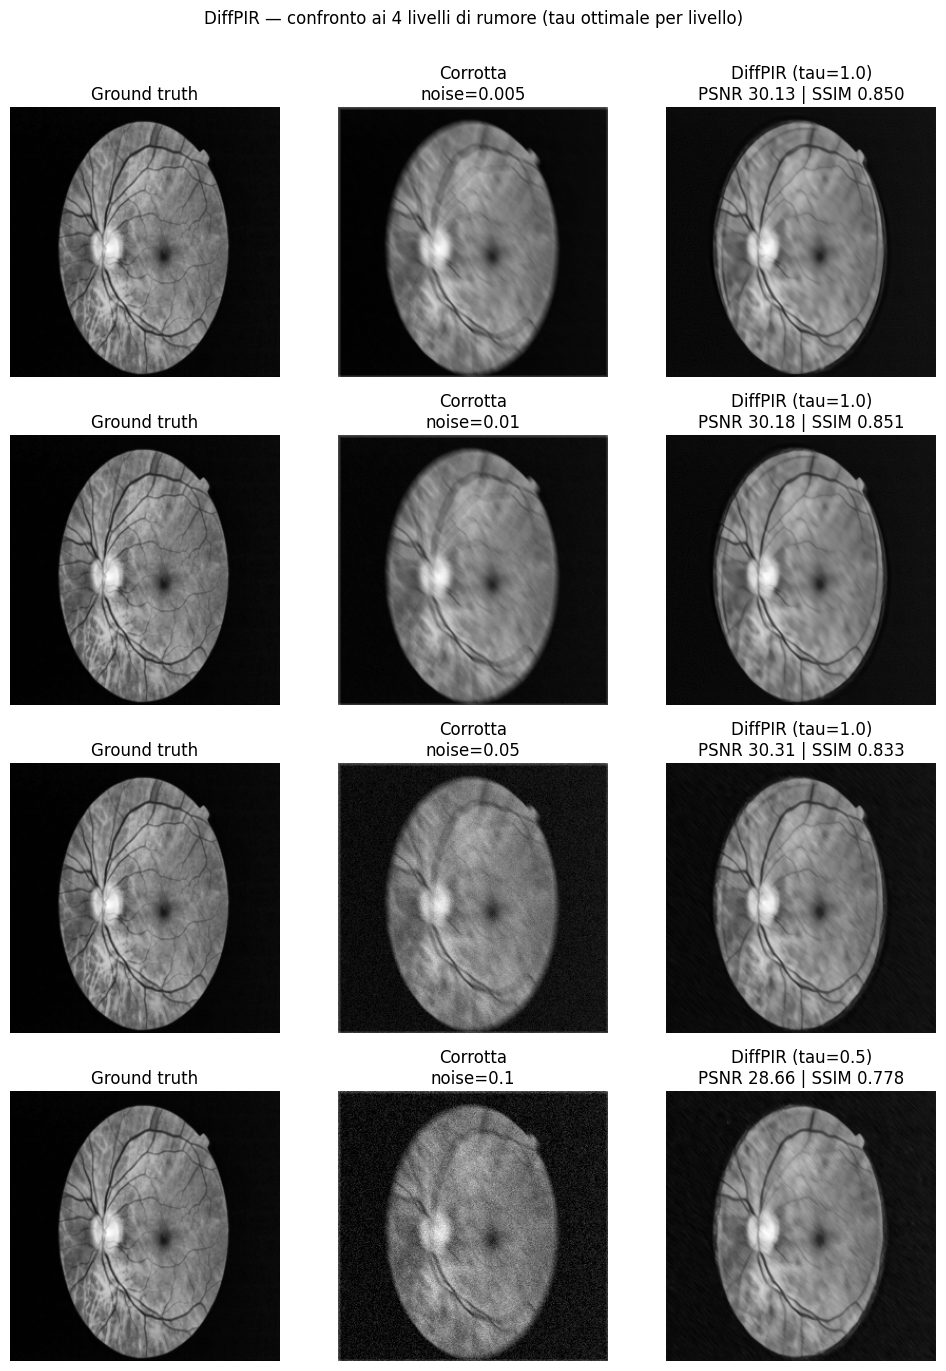

In [ ]:
import matplotlib.pyplot as plt

# tau ottimale per livello
best_tau = {0.005: 1.0, 0.01: 1.0, 0.05: 1.0, 0.1: 0.5}
noise_levels = [0.005, 0.01, 0.05, 0.1]

# Immagine di test fissa
idx = 1
x_true = test_dataset[idx].unsqueeze(0).to(device)
x_true_01 = denormalize_to_01(x_true).cpu()

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(10, 3.4 * len(noise_levels)))

for r, nl in enumerate(noise_levels):
    tau = best_tau[nl]
    torch.manual_seed(idx)
    with torch.no_grad():
        y_delta = K(x_true) + nl * torch.randn_like(x_true)
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)

    y_01   = denormalize_to_01(y_delta).cpu()
    rec_01 = denormalize_to_01(x_rec).cpu()
    psnr   = PSNR(rec_01, x_true_01)
    ssim   = SSIM(rec_01, x_true_01)

    axes[r, 0].imshow(x_true_01.squeeze(), cmap='gray')
    axes[r, 0].set_title('Ground truth'); axes[r, 0].axis('off')
    axes[r, 1].imshow(y_01.squeeze(), cmap='gray')
    axes[r, 1].set_title(f'Corrotta\nnoise={nl}'); axes[r, 1].axis('off')
    axes[r, 2].imshow(rec_01.squeeze(), cmap='gray')
    axes[r, 2].set_title(f'DiffPIR (tau={tau})\nPSNR {psnr:.2f} | SSIM {ssim:.3f}')
    axes[r, 2].axis('off')

plt.suptitle('DiffPIR — confronto ai 4 livelli di rumore (tau ottimale per livello)', y=1.005)
plt.tight_layout(); plt.show()

Ecco i risultati sui 4 livelli diversi di rumore e con rispettivo tau ottimale

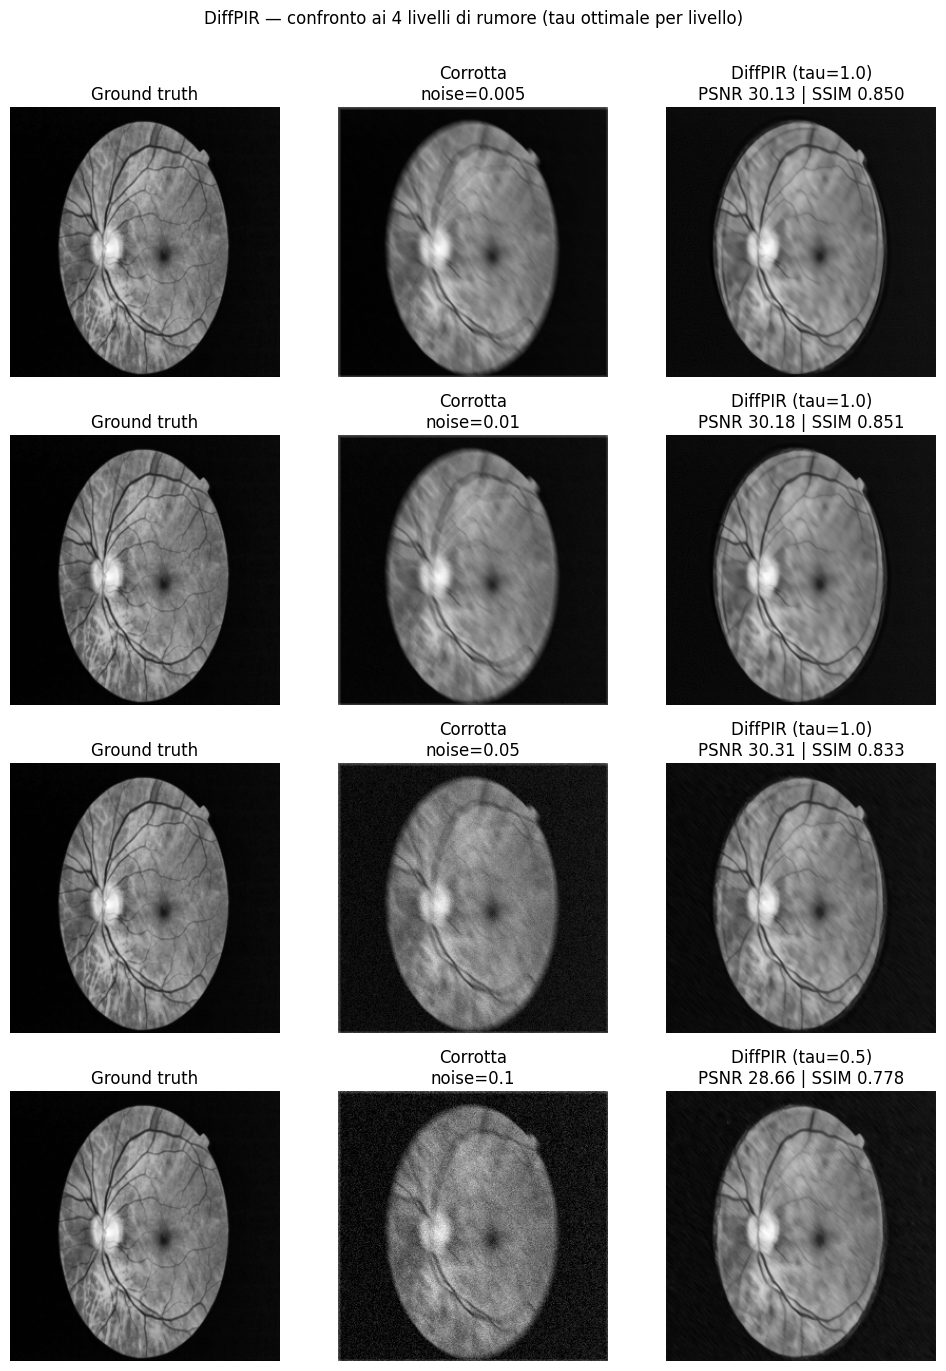

# Tau ottimale vs livello di rumore


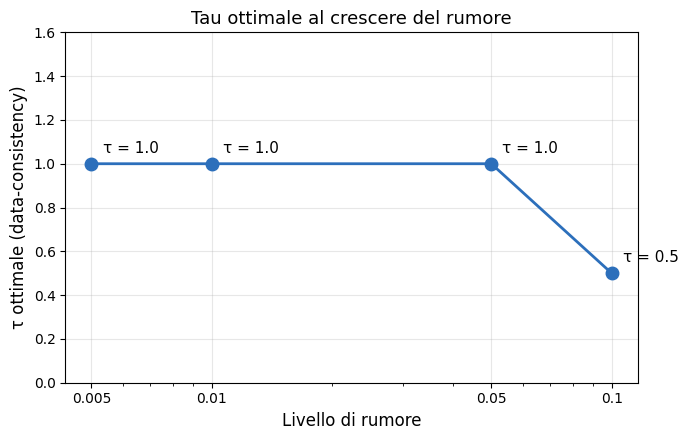

In [ ]:
import matplotlib.pyplot as plt

# Risultati della taratura per livello di rumore
noise_levels = [0.005, 0.01, 0.05, 0.1]
best_tau = [1.0, 1.0, 1.0, 0.5]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(noise_levels, best_tau, 'o-', color='#2c6fbb', linewidth=2, markersize=9)

# Etichette del valore di tau accanto a ogni punto
for nl, tau in zip(noise_levels, best_tau):
    ax.annotate(f'τ = {tau}', (nl, tau),
                textcoords='offset points', xytext=(8, 8), fontsize=11)

ax.set_xscale('log')   # i livelli di rumore sono su scala logaritmica
ax.set_xticks(noise_levels)
ax.set_xticklabels([str(nl) for nl in noise_levels])
ax.set_xlabel('Livello di rumore', fontsize=12)
ax.set_ylabel('τ ottimale (data-consistency)', fontsize=12)
ax.set_title('Tau ottimale al crescere del rumore', fontsize=13)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.6)

plt.tight_layout()
plt.show()

# Metriche vs Livello di Rumore

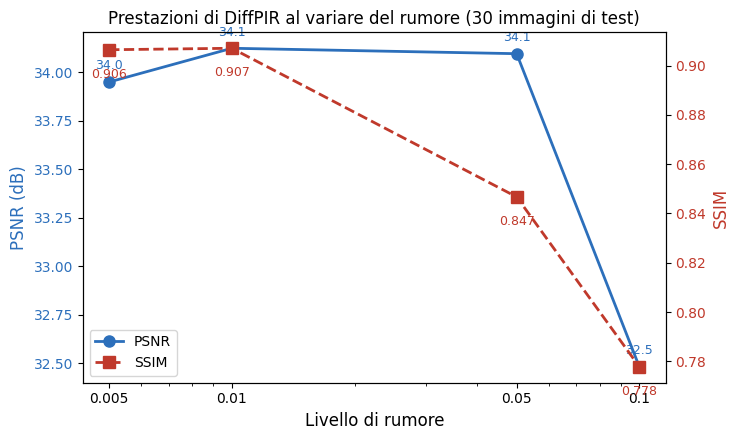

In [ ]:
import matplotlib.pyplot as plt

# Valori finali della valutazione su 30 immagini
noise_levels = [0.005, 0.01, 0.05, 0.1]
psnr_vals    = [33.950, 34.124, 34.096, 32.481]
ssim_vals    = [0.9064, 0.9070, 0.8467, 0.7778]

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))

# Asse sinistro: PSNR
color1 = '#2c6fbb'
ax1.plot(noise_levels, psnr_vals, 'o-', color=color1, linewidth=2, markersize=8, label='PSNR')
ax1.set_xlabel('Livello di rumore', fontsize=12)
ax1.set_ylabel('PSNR (dB)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xscale('log')
ax1.set_xticks(noise_levels)
ax1.set_xticklabels([str(nl) for nl in noise_levels])

# Asse destro: SSIM
ax2 = ax1.twinx()
color2 = '#c0392b'
ax2.plot(noise_levels, ssim_vals, 's--', color=color2, linewidth=2, markersize=8, label='SSIM')
ax2.set_ylabel('SSIM', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Etichette dei valori sui punti
for nl, p in zip(noise_levels, psnr_vals):
    ax1.annotate(f'{p:.1f}', (nl, p), textcoords='offset points', xytext=(0, 9),
                 fontsize=9, color=color1, ha='center')
for nl, s in zip(noise_levels, ssim_vals):
    ax2.annotate(f'{s:.3f}', (nl, s), textcoords='offset points', xytext=(0, -20),
                 fontsize=9, color=color2, ha='center')

plt.title('Prestazioni di DiffPIR al variare del rumore (30 immagini di test)', fontsize=12)
fig.tight_layout()

# Legenda combinata (PSNR + SSIM)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

plt.show()